## Imports

In [1]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from extract_data import extract_data_from_folder, parse_condition_intervals
import pandas as pd
import seaborn as sns
from scipy import stats


## Constants & Helpers

In [2]:
SAMPLING_RATE         = 51.2
GSR_COL               = 'Shimmer_A679_GSR_Skin_Conductance_CAL'
PPG_COL               = 'Shimmer_A679_PPG_A13_CAL'
TS_COL                = 'Shimmer_A679_TimestampSync_Unix_CAL'  # milliseconds
TEMP_COL              = 'Shimmer_A679_Temperature_BMP280_CAL'  # °C — varies 1–3°C within session
# PRESSURE_COL excluded: BMP280 reads atmospheric pressure (~100 kPa), not blood pressure;
# near-constant within-session (std < 0.04 kPa) — carries no stress signal.
INSTRUCTION_SEC_LVL0  = 31
MIN_CLEAN_SEC         = 5
BUFFER_TIME           = 1  # seconds to drop between explanation and task


In [3]:
def trim_level(level_df, level_num, mode="task"):
    """
    mode='task':        drop the explanation period, return the task portion.
    mode='explanation': keep only the explanation period (level 0 only; other levels return empty).
    mode='full':        no trimming — raw data as recorded.

    Uses timestamps instead of sample counts to be robust to dropped samples.
    """
    if len(level_df) == 0:
        return level_df.iloc[0:0]

    ts = level_df[TS_COL]
    t0 = ts.iloc[0]
    cutoff = t0 + INSTRUCTION_SEC_LVL0 * 1000  # ms

    if mode == "explanation":
        if level_num != 0:
            return level_df.iloc[0:0]
        segment = level_df[ts < cutoff]
        if len(segment) < int(MIN_CLEAN_SEC * SAMPLING_RATE):
            return level_df.iloc[0:0]
        return segment

    if mode == "task":
        if level_num == 0:
            remaining = level_df[ts >= cutoff + BUFFER_TIME]
        else:
            remaining = level_df
        if len(remaining) < int(MIN_CLEAN_SEC * SAMPLING_RATE):
            return level_df.iloc[0:0]
        return remaining

    return level_df  # mode='full': no trimming


def get_clean_group(subject_df, condition, rep, mode="task"):
    """For a given condition/rep, trim each level and concatenate the valid parts."""
    group = subject_df[(subject_df['condition'] == condition) & (subject_df['rep'] == rep)]
    trimmed_parts = []
    for level_num in sorted(group['level'].unique()):
        level_df = group[group['level'] == level_num]
        trimmed = trim_level(level_df, level_num, mode=mode)
        if len(trimmed) > 0:
            trimmed_parts.append(trimmed)
    if not trimmed_parts:
        return None
    return pd.concat(trimmed_parts, ignore_index=True)


In [4]:
def clean_eda(signal, sampling_rate=SAMPLING_RATE):
    """
    Remove sampling artefact spikes from raw EDA.

    Spikes are defined as samples exceeding BOTH:
      - absolute threshold: > 45 µS
      - relative threshold: > 5× signal median
    Spike samples are replaced with NaN and filled via linear interpolation
    (forward-fill / back-fill at edges). Spikes are always a few ms wide and
    do not appear to affect surrounding signal.
    """
    median = np.median(signal)
    spike_mask = signal > min(45, median * 5)
    cleaned = signal.copy().astype(float)
    cleaned[spike_mask] = np.nan
    cleaned = pd.Series(cleaned).interpolate(method='linear').bfill().ffill().values
    return cleaned


In [5]:
def compute_basic_eda_metrics(df, normalized=True):
    signals, info = nk.eda_process(clean_eda(df[GSR_COL].values), sampling_rate=SAMPLING_RATE)

    scr_peaks = signals['SCR_Peaks'] == 1
    scr_amps  = signals.loc[scr_peaks, 'SCR_Amplitude']

    dt     = 1.0 / SAMPLING_RATE
    phasic = signals['EDA_Phasic'].values

    onsets     = np.array(info.get('SCR_Onsets', []))
    peaks      = np.array(info.get('SCR_Peaks', []))
    recoveries = np.array(info.get('SCR_Recovery', []))

    # Rise time = peak - onset
    if len(onsets) > 0 and len(peaks) > 0:
        n = min(len(onsets), len(peaks))
        rise_samples = peaks[:n] - onsets[:n]
        rise_times = rise_samples[rise_samples > 0] / SAMPLING_RATE
        mean_rise_time = rise_times.mean() if len(rise_times) > 0 else 0.0
    else:
        mean_rise_time = 0.0

    # Half-recovery time = recovery - peak
    if len(peaks) > 0 and len(recoveries) > 0:
        n = min(len(peaks), len(recoveries))
        rec_samples = recoveries[:n] - peaks[:n]
        valid = rec_samples[~np.isnan(rec_samples)]
        valid = valid[valid > 0]
        mean_recovery_time = (valid / SAMPLING_RATE).mean() if len(valid) > 0 else 0.0
    else:
        mean_recovery_time = 0.0

    # WAMP: number of phasic differences exceeding 2× median absolute difference.
    # Adaptive per subject. Captures activity level without peak detection.
    diffs = np.abs(np.diff(phasic))
    wamp_threshold = np.median(diffs) * 2
    wamp = np.sum(diffs > wamp_threshold)

    mean_tonic = signals['EDA_Tonic'].mean()
    scr_count  = scr_peaks.sum()
    peak_amp   = scr_amps.max() if len(scr_amps) > 0 else 0.0
    phasic_auc = float(np.sum(np.abs(phasic)) * dt)
    entropy    = nk.entropy_sample(signals['EDA_Raw'])[0]

    if normalized:
        return {
            'log_mean_tonic_uS':          np.log(mean_tonic),
            'sqrt_scr_count':             np.sqrt(scr_count),
            'log1p_peak_scr_amp_uS':      np.log1p(peak_amp),
            'log1p_phasic_auc_abs_uS_s':  np.log1p(phasic_auc),
            'raw_entropy':                entropy,
            'log1p_mean_rise_time_s':     np.log1p(mean_rise_time),
            'log1p_mean_recovery_time_s': np.log1p(mean_recovery_time),
            'sqrt_wamp':                  np.sqrt(wamp),
        }
    else:
        return {
            'mean_tonic_uS':       mean_tonic,
            'scr_count':           scr_count,
            'peak_scr_amp_uS':     peak_amp,
            'phasic_auc_abs_uS_s': phasic_auc,
            'raw_entropy':         entropy,
            'mean_rise_time_s':    mean_rise_time,
            'mean_recovery_time_s': mean_recovery_time,
            'wamp':                wamp,
        }


In [6]:
def compute_hrv_metrics(df, normalized=True):
    # neurokit2 uses an older pandas API — deprecation warnings are expected and harmless.
    signals, info = nk.ppg_process(df[PPG_COL].values, sampling_rate=SAMPLING_RATE)
    hrv = nk.hrv(info, sampling_rate=SAMPLING_RATE)

    meanNN = hrv['HRV_MeanNN'].values[0]
    sdnn   = hrv['HRV_SDNN'].values[0]
    rmssd  = hrv['HRV_RMSSD'].values[0]
    lf_hf  = hrv['HRV_LFHF'].values[0]

    if normalized:
        return {
            'hrv_meanNN':    meanNN,
            'log_hrv_sdnn':  np.log(sdnn),
            'log_hrv_rmssd': np.log(rmssd),
            'log_hrv_lf_hf': np.log(lf_hf),
        }
    else:
        return {
            'hrv_meanNN': meanNN,
            'hrv_sdnn':   sdnn,
            'hrv_rmssd':  rmssd,
            'hrv_lf_hf':  lf_hf,
        }


In [7]:
def compute_temperature_metrics(df, normalized=True):
    # BMP280 temperature (27–34°C) reflects skin/device contact.
    # May serve as a peripheral vasoconstriction proxy under sympathetic arousal.
    # Note: a small number of subjects have glitch spikes (< 0°C) in this channel.
    temperature = df[TEMP_COL].dropna().values
    mean_temp = float(np.mean(temperature))
    std_temp  = float(np.std(temperature))

    if normalized:
        return {
            'mean_temp_C':      mean_temp,
            'log1p_std_temp_C': np.log1p(std_temp),
        }
    else:
        return {
            'mean_temp_C': mean_temp,
            'std_temp_C':  std_temp,
        }


In [8]:
def compute_all_metrics(all_subjects, mode="task", normalized=True):
    """
    Compute per-(subject, condition, rep) metrics for all subjects.

    mode='task':        task periods only (explanation trimmed from level 0)
    mode='explanation': only the 30 s instruction period from level 0
    mode='full':        raw / untrimmed segments

    normalized=True:  apply log / sqrt / log1p transforms for ANOVA assumptions
    normalized=False: raw metric values
    """
    rows = []
    for subject_id, subject_df in all_subjects.items():
        for (condition, rep), group in subject_df.groupby(['condition', 'rep']):
            if mode in ("task", "explanation"):
                clean_group = get_clean_group(subject_df, condition, rep, mode=mode)
            else:
                clean_group = group
            if clean_group is not None:
                try:
                    m  = compute_basic_eda_metrics(clean_group, normalized=normalized)
                    h  = compute_hrv_metrics(clean_group, normalized=normalized)
                    bp = compute_temperature_metrics(clean_group, normalized=normalized)
                    rows.append({'subject_id': subject_id, 'condition': condition, 'rep': rep,
                                 **m, **h, **bp})
                except Exception as e:
                    print(f"Failed {subject_id} {condition} rep{rep}: {e}")
    return pd.DataFrame(rows)


def plot_metric(subject_df, metric, normalized=True):
    """Bar chart of one metric across all (condition, rep) pairs for a single subject."""
    rows = []
    for (condition, rep), group in subject_df.groupby(['condition', 'rep']):
        try:
            m = compute_basic_eda_metrics(group, normalized=normalized)
            rows.append({'label': f'{condition}_rep{rep}', 'value': m[metric]})
        except Exception as e:
            print(f"Failed {condition} rep{rep}: {e}")
            break
    df = pd.DataFrame(rows).set_index('label')
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(df.index, df['value'])
    ax.set_title(metric)
    ax.set_xticks(range(len(df.index)))
    ax.set_xticklabels(df.index, rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()


## Load Data

In [9]:
all_subjects = extract_data_from_folder()


Loaded 28949: 82019 rows
Loaded 48203: 90523 rows
Loaded 55131: 83403 rows
Loaded 63264: 86167 rows
Loaded 63817: 79571 rows
Loaded 69316: 110232 rows
Loaded 85418: 83356 rows
Loaded 9999999: 78631 rows
Loaded 11334: 72799 rows
Loaded 26880: 72473 rows
Loaded 47441: 85707 rows
Loaded 57261: 77867 rows
Loaded 59688: 93440 rows
Loaded 69905: 84387 rows
Loaded 85824: 80704 rows
Loaded 96755: 90043 rows
Loaded 3283: 92881 rows
Loaded 21234: 100656 rows
Loaded 23197: 57519 rows
Loaded 23487: 69162 rows
Loaded 26084: 85730 rows
Loaded 53416: 80411 rows
Loaded 55723: 87643 rows
Loaded 69661: 69498 rows
Loaded 73757: 76441 rows
Loaded 78624: 88876 rows
Loaded 97750: 86903 rows
Loaded 99572: 55954 rows
Loaded 22644: 88724 rows
Loaded 24549: 66008 rows
Loaded 45377: 78409 rows
Loaded 57274: 70983 rows
Loaded 62565: 59196 rows
Loaded 66505: 65942 rows
Loaded 67455: 75489 rows
Loaded 81264: 76723 rows
Loaded 87463: 69772 rows
Loaded 35264: 89981 rows
Loaded 70677: 66471 rows
Loaded 7144: 78744 row

## Export Metrics

Produces 6 CSVs: all combinations of `mode` (full / task / explanation) × `normalized` (True / False).
One row per `(subject, condition, rep)`.

In [10]:
for mode in ("full", "task", "explanation"):
    for norm in (True, False):
        tag = f"{mode}_{'normalized' if norm else 'raw'}"
        df = compute_all_metrics(all_subjects, mode=mode, normalized=norm)
        df.to_csv(f"tagged_metrics_{tag}.csv", index=False)
        print(f"{tag}: {len(df)} rows")


KeyboardInterrupt: 

## Export Level Timestamps

Wide-format table with per-level start (and final-level end) timestamps relative to segment start, in seconds.

In [11]:
def compute_level_timestamps_wide(all_subjects):
    rows = []
    for subject_id, subject_df in all_subjects.items():
        level_intervals = parse_condition_intervals(subject_id)
        for (condition, rep), seg in subject_df.groupby(['condition', 'rep']):
            seg_start_ms = seg[TS_COL].iloc[0]
            levels = level_intervals[
                (level_intervals['condition'] == condition) &
                (level_intervals['rep'] == rep)
            ].sort_values('level')
            row = {'subject_id': subject_id, 'condition': condition, 'rep': rep}
            if len(levels) > 0:
                for _, lvl in levels.iterrows():
                    lvl_num = int(lvl['level'])
                    row[f'lvl{lvl_num}_start'] = round((lvl['start'] - seg_start_ms) / 1000, 3)
                last = levels.iloc[-1]
                last_num = int(last['level'])
                row[f'lvl{last_num}_end'] = round((last['end'] - seg_start_ms) / 1000, 3)
            rows.append(row)
    df = pd.DataFrame(rows).fillna(-1)
    return df


level_timestamps_df = compute_level_timestamps_wide(all_subjects)
level_timestamps_df.to_csv("level_timestamps.csv", index=False)
print(f"Saved level_timestamps.csv — {len(level_timestamps_df)} rows")


Saved level_timestamps.csv — 317 rows


## Export Sampling QC

Checks what percentage of expected samples were actually recorded per level.
Useful for spotting dropped data or Shimmer disconnections.

In [12]:
def compute_sampling_qc(all_subjects, expected_fs=SAMPLING_RATE):
    rows = []
    for subject_id, subject_df in all_subjects.items():
        level_intervals = parse_condition_intervals(subject_id)
        for (condition, rep), grp in level_intervals.groupby(['condition', 'rep']):
            row = {'subject_id': subject_id, 'condition': condition, 'rep': rep}
            for _, lvl in grp.iterrows():
                actual   = ((subject_df['condition'] == condition) &
                            (subject_df['rep'] == rep) &
                            (subject_df['level'] == lvl['level'])).sum()
                expected = (lvl['end'] - lvl['start']) / 1000.0 * expected_fs
                row[f'lvl{int(lvl["level"])}_pct'] = round(actual / expected * 100, 1) if expected > 0 else 0.0
            rows.append(row)
    return pd.DataFrame(rows)


sampling_qc_df = compute_sampling_qc(all_subjects)
sampling_qc_df.to_csv("sampling_qc.csv", index=False)
print(f"Saved sampling_qc.csv — {len(sampling_qc_df)} rows")


Saved sampling_qc.csv — 318 rows


---
## Debug Views

The cells below are for manual inspection and are not part of the main pipeline.
They do not write any output files.

### Accelerometer vs EDA

Overlay of raw EDA, tonic component, and accelerometer jerk for one subject/condition.
Useful for spotting motion artefacts that survived `clean_eda`.

**Edit `SUBJECT_ID`, `CONDITION`, and `REP` below before running.**

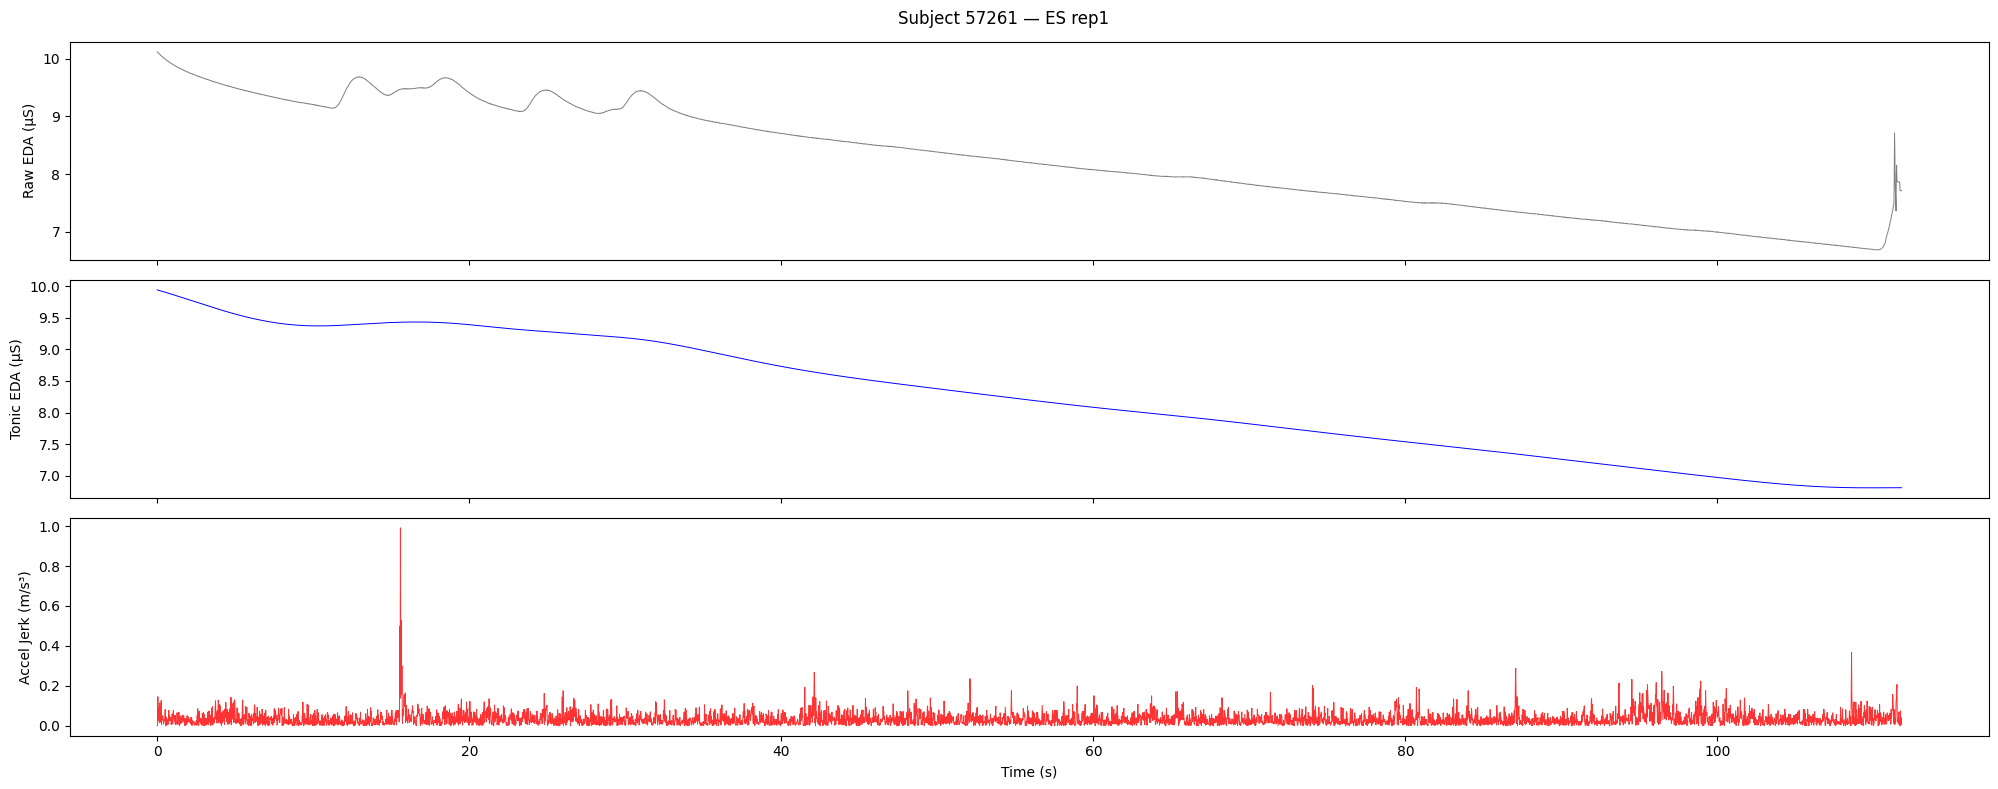

In [13]:
SUBJECT_ID = '57261'
CONDITION  = 'ES'
REP        = 1

ACCEL_COLS = [
    'Shimmer_A679_Accel_LN_X_CAL',
    'Shimmer_A679_Accel_LN_Y_CAL',
    'Shimmer_A679_Accel_LN_Z_CAL',
]

subject_df = all_subjects[SUBJECT_ID]
seg = subject_df[(subject_df['condition'] == CONDITION) & (subject_df['rep'] == REP)]

accel     = seg[ACCEL_COLS].values
accel_mag = np.sqrt((accel ** 2).sum(axis=1))
jerk      = np.abs(np.diff(accel_mag, prepend=accel_mag[0]))

cleaned_eda = clean_eda(seg[GSR_COL].values)
signals, _  = nk.eda_process(cleaned_eda, sampling_rate=SAMPLING_RATE)
t = np.arange(len(seg)) / SAMPLING_RATE

fig, axes = plt.subplots(3, 1, figsize=(20, 8), sharex=True)
fig.suptitle(f'Subject {SUBJECT_ID} — {CONDITION} rep{REP}', fontsize=12)

axes[0].plot(t, cleaned_eda, color='gray', linewidth=0.7)
axes[0].set_ylabel('Raw EDA (µS)')

axes[1].plot(t, signals['EDA_Tonic'].values, color='blue', linewidth=0.7)
axes[1].set_ylabel('Tonic EDA (µS)')

axes[2].plot(t, jerk, color='red', linewidth=0.7, alpha=0.8)
axes[2].set_ylabel('Accel Jerk (m/s³)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()


### Per-Subject EDA Signal PDF

Generates `eda_signals.pdf` with one page per subject, showing tonic, phasic, and raw EDA
for each condition (rep 0 only). Level boundaries are marked as dashed vertical lines.

In [14]:
CONDITION_COLORS = {
    'ES':       'tab:red',
    'NE':       'tab:blue',
    'ES_empty': 'tab:orange',
    'NE_empty': 'tab:cyan',
}

with PdfPages('eda_signals.pdf') as pdf:
    for subject_id, subject_df in all_subjects.items():
        level_intervals = parse_condition_intervals(subject_id)

        fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=False)
        fig.suptitle(f'Subject {subject_id}', fontsize=13)
        level_lines = []

        for condition, color in CONDITION_COLORS.items():
            for rep in [0]:  # change to [0, 1] to include both repetitions
                seg = subject_df[
                    (subject_df['condition'] == condition) & (subject_df['rep'] == rep)
                ]
                if len(seg) == 0:
                    continue
                try:
                    cleaned = clean_eda(seg[GSR_COL].values)
                    signals, _ = nk.eda_process(cleaned, sampling_rate=SAMPLING_RATE)
                    t = np.arange(len(seg)) / SAMPLING_RATE

                    axes[0].plot(t, signals['EDA_Tonic'].values, color=color, label=f"{condition} rep{rep}")
                    axes[1].plot(t, signals['EDA_Phasic'].values, color=color)
                    axes[2].plot(t, signals['EDA_Raw'].values, color=color)

                    levels = level_intervals[
                        (level_intervals['condition'] == condition) &
                        (level_intervals['rep'] == rep)
                    ].sort_values('level')

                    if len(levels) > 0:
                        seg_start_ms = seg[TS_COL].iloc[0]
                        for _, lvl in levels.iterrows():
                            t_level = (lvl['start'] - seg_start_ms) / 1000
                            for ax in axes:
                                ax.axvline(t_level, color=color, alpha=0.3, linestyle='--')
                            level_lines.append((t_level, color, int(lvl['level'])))

                except Exception as e:
                    print(f"Failed {subject_id} {condition} rep{rep}: {e}")

        top = axes[0].get_ylim()[1]
        for t_level, color, level_num in level_lines:
            axes[0].text(t_level, top, f"L{level_num}",
                         fontsize=6, color=color, alpha=0.7, ha='center', va='top')

        axes[0].set_ylabel('Tonic')
        axes[1].set_ylabel('Phasic')
        axes[2].set_ylabel('Raw')
        axes[2].set_xlabel('Time (s)')
        axes[0].legend(fontsize=8)
        plt.tight_layout()
        pdf.savefig(fig, dpi=600)
        plt.close(fig)

print("Saved eda_signals.pdf")


Saved eda_signals.pdf
